# Prediksi Customer Churn Perusahaan Telekomunikasi
### Proyek Kelompok - Pengembangan Sistem Pembelajaran Mesin

**Mata Kuliah:** Pemelajaran Mesin
**Program Studi Teknik Informatika, Universitas 17 Agustus 1945 Surabaya**

---

## 1. Identifikasi Masalah Organisasi

Perusahaan telekomunikasi menghadapi masalah **churn pelanggan** (pelanggan berhenti berlangganan). Kehilangan pelanggan berdampak langsung pada pendapatan, dan biaya akuisisi pelanggan baru jauh lebih mahal dibanding mempertahankan pelanggan lama.

**Tujuan bisnis:** membangun sistem yang dapat memprediksi pelanggan mana yang berisiko churn, sehingga tim retensi dapat melakukan intervensi (misalnya penawaran khusus) sebelum pelanggan tersebut benar-benar berhenti.


## 2. Analisis Karakteristik Data & Pemilihan Pendekatan ML

Dataset yang digunakan adalah **Telco Customer Churn** (7.043 pelanggan, 21 atribut), berisi data demografi pelanggan, layanan yang digunakan, informasi kontrak, dan status churn (label `Yes`/`No`).

**Justifikasi pemilihan pendekatan:**
- Data memiliki **label target yang jelas** (`Churn`: Yes/No) untuk setiap baris data historis.
- Tujuan tugas adalah **memprediksi kategori** (churn / tidak churn) berdasarkan atribut pelanggan.
- Karena tersedia label dan tujuannya adalah prediksi kategori, pendekatan yang paling sesuai adalah **Supervised Learning**, khususnya **klasifikasi biner**.
- Unsupervised learning tidak dipilih karena tidak memanfaatkan label yang sudah tersedia (kurang optimal untuk kebutuhan prediksi langsung). Reinforcement learning tidak sesuai karena tidak ada proses pengambilan keputusan sekuensial/reward yang eksplisit dalam data ini.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)

sns.set_style("whitegrid")
df = pd.read_csv("telco_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nDistribusi target:\n", df['Churn'].value_counts(normalize=True))

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 2.1 Eksplorasi Data Awal (EDA)

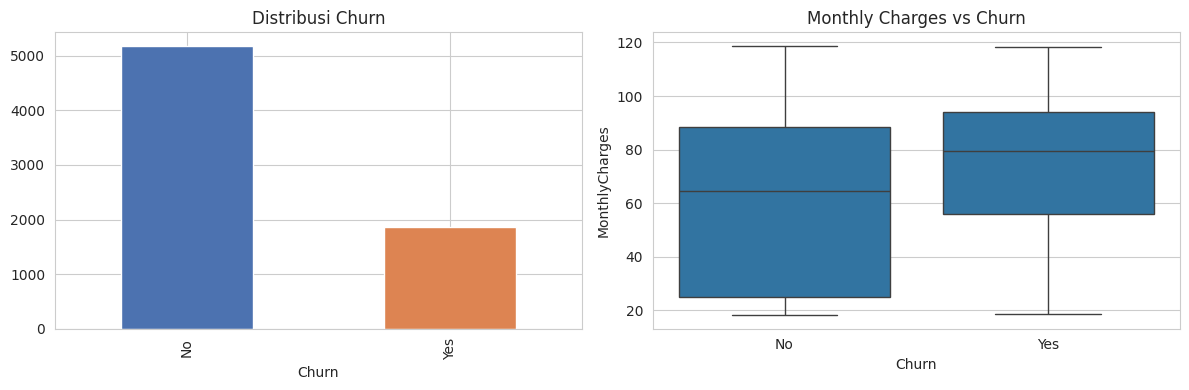

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
df['Churn'].value_counts().plot(kind='bar', ax=ax[0], color=['#4C72B0','#DD8452'])
ax[0].set_title('Distribusi Churn')
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=ax[1])
ax[1].set_title('Monthly Charges vs Churn')
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120)
plt.show()

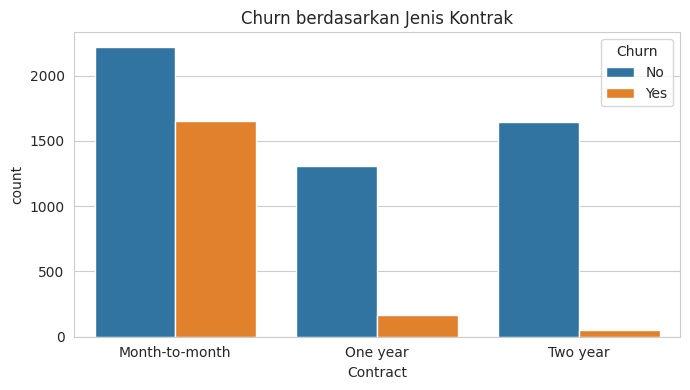

In [4]:
fig, ax = plt.subplots(figsize=(7,4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn berdasarkan Jenis Kontrak')
plt.tight_layout()
plt.savefig('eda_contract.png', dpi=120)
plt.show()

**Insight awal:** Pelanggan dengan kontrak *month-to-month* dan biaya bulanan tinggi cenderung memiliki tingkat churn lebih besar dibanding pelanggan dengan kontrak jangka panjang.

## 3. Preprocessing Data

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df.drop('customerID', axis=1, inplace=True)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in df.columns if c not in cat_cols and c != 'Churn']

encoders = {}
df_enc = df.copy()
for c in cat_cols:
    le = LabelEncoder()
    df_enc[c] = le.fit_transform(df_enc[c])
    encoders[c] = le

X = df_enc.drop('Churn', axis=1)
y = df_enc['Churn']
print(X.shape, y.shape)

(7043, 19) (7043,)


/tmp/ipykernel_584/1607297467.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (5634, 19) Test: (1409, 19)


## 4. Pengembangan Model Machine Learning

Dua model diuji dan dibandingkan:
1. **Logistic Regression** — model linear, mudah diinterpretasi, baseline yang baik untuk klasifikasi biner.
2. **Random Forest** — model ensemble berbasis pohon keputusan, mampu menangkap hubungan non-linear antar fitur.

Kedua model menggunakan `class_weight='balanced'` karena distribusi kelas churn tidak seimbang (±26% churn vs ±74% tidak churn).


In [7]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train_s, y_train)
pred_lr = log_reg.predict(X_test_s)
proba_lr = log_reg.predict_proba(X_test_s)[:,1]

rf = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:,1]

## 5. Evaluasi Kinerja Model

In [8]:
def evaluate(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1-Score": round(f1_score(y_true, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_true, y_proba), 4)
    }

results_df = pd.DataFrame([
    evaluate("Logistic Regression", y_test, pred_lr, proba_lr),
    evaluate("Random Forest", y_test, pred_rf, proba_rf)
])
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7395,0.5059,0.7968,0.6189,0.8396
1,Random Forest,0.7665,0.5427,0.7647,0.6349,0.8420


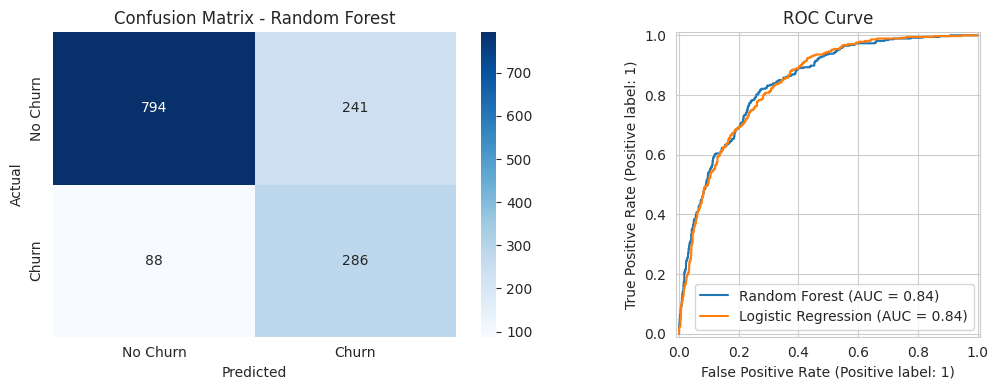

              precision    recall  f1-score   support

    No Churn       0.90      0.77      0.83      1035
       Churn       0.54      0.76      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409



In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
for name, pred in [("Logistic Regression", pred_lr), ("Random Forest", pred_rf)]:
    pass

cm = confusion_matrix(y_test, pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'], ax=axes[0])
axes[0].set_title('Confusion Matrix - Random Forest')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

RocCurveDisplay.from_predictions(y_test, proba_rf, ax=axes[1], name='Random Forest')
RocCurveDisplay.from_predictions(y_test, proba_lr, ax=axes[1], name='Logistic Regression')
axes[1].set_title('ROC Curve')
plt.tight_layout()
plt.savefig('eval_metrics.png', dpi=120)
plt.show()

print(classification_report(y_test, pred_rf, target_names=['No Churn','Churn']))

**Pemilihan model terbaik:** Random Forest dipilih sebagai model final karena memiliki F1-Score dan Recall tertinggi — penting dalam konteks bisnis ini karena **kesalahan gagal mendeteksi pelanggan yang akan churn (False Negative) lebih merugikan** dibanding salah menandai pelanggan yang sebenarnya loyal.

## 6. Interpretasi Hasil Model & Implikasi Bisnis

/tmp/ipykernel_584/3403130859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


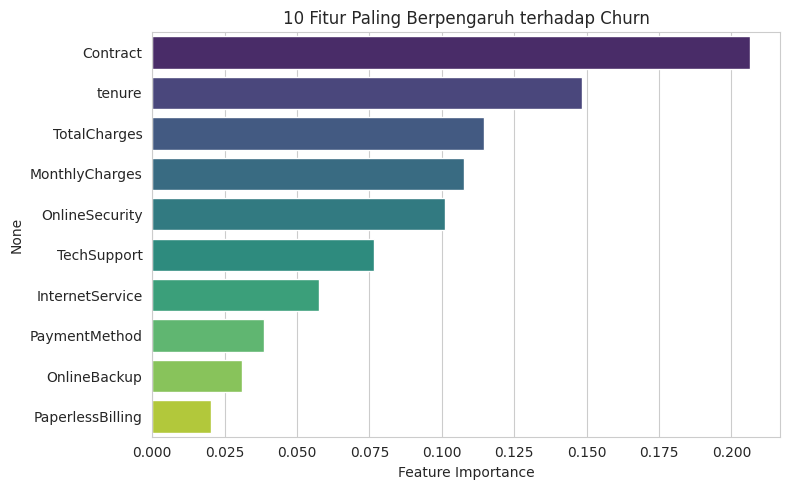

Contract            0.206479
tenure              0.148249
TotalCharges        0.114615
MonthlyCharges      0.107773
OnlineSecurity      0.101120
TechSupport         0.076482
InternetService     0.057613
PaymentMethod       0.038614
OnlineBackup        0.031132
PaperlessBilling    0.020134
dtype: float64

In [10]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('10 Fitur Paling Berpengaruh terhadap Churn')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()
importances

**Interpretasi bisnis:**
- **Jenis kontrak (`Contract`)** adalah faktor paling berpengaruh — pelanggan bulanan jauh lebih rentan churn dibanding kontrak tahunan. Organisasi dapat mendorong migrasi ke kontrak jangka panjang lewat insentif harga.
- **Lama berlangganan (`tenure`)** dan **total biaya (`TotalCharges`)** berkorelasi dengan loyalitas — pelanggan baru berisiko lebih tinggi, sehingga onboarding di bulan-bulan awal perlu diperkuat.
- **Layanan keamanan online (`OnlineSecurity`) dan dukungan teknis (`TechSupport`)** yang tidak diaktifkan berkorelasi dengan churn lebih tinggi, mengindikasikan pentingnya edukasi/penawaran bundling layanan tersebut.

**Rekomendasi untuk organisasi:** gunakan skor probabilitas churn dari model untuk memprioritaskan pelanggan berisiko tinggi dalam kampanye retensi, dengan fokus pada pelanggan kontrak bulanan dan pelanggan baru (tenure rendah).

## 7. Deployment Model

In [11]:
import joblib
joblib.dump(rf, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoders, 'encoders.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')
print("Model dan artefak berhasil disimpan untuk digunakan pada aplikasi web (app.py).")

Model dan artefak berhasil disimpan untuk digunakan pada aplikasi web (app.py).


Model yang telah disimpan (`churn_model.pkl`, `scaler.pkl`, `encoders.pkl`, `feature_columns.pkl`) digunakan oleh aplikasi web (`app.py`, dibangun dengan **Streamlit**) agar pengguna dapat memasukkan data pelanggan baru dan memperoleh prediksi risiko churn secara interaktif. Lihat file `app.py` pada repository proyek.

## 8. Refleksi Etika dalam Penggunaan AI

- **Potensi bias data:** dataset merepresentasikan populasi pelanggan pada periode dan wilayah tertentu; model dapat kurang akurat bila diterapkan pada segmen pelanggan yang berbeda karakteristiknya (mis. wilayah baru, jenis layanan baru). Perlu evaluasi ulang berkala (*model monitoring*) dan retraining dengan data yang representatif.
- **Transparansi model:** Random Forest tidak sepenuhnya "black box" karena feature importance dapat diinterpretasikan, namun tetap kurang transparan dibanding model linear. Untuk kebutuhan audit, laporan feature importance dan confusion matrix perlu didokumentasikan dan disampaikan ke pemangku kepentingan.
- **Dampak terhadap organisasi dan pelanggan:** prediksi churn sebaiknya digunakan untuk **menawarkan nilai tambah** (diskon, layanan tambahan) kepada pelanggan berisiko, bukan untuk tindakan yang merugikan pelanggan (mis. menaikkan harga secara sepihak berdasarkan skor churn). Keputusan otomatis penuh (tanpa tinjauan manusia) sebaiknya dihindari untuk keputusan yang berdampak signifikan pada pelanggan individu.

## 9. Kesimpulan

Model Random Forest berhasil memprediksi churn pelanggan dengan performa yang baik (ROC-AUC ±0.84) dan memberikan interpretasi faktor-faktor penyebab churn yang dapat ditindaklanjuti secara bisnis. Sistem ini telah di-deploy dalam bentuk aplikasi web sederhana agar dapat digunakan secara interaktif oleh tim organisasi.
